# PASO 1: Inyección del Sistema y Configuración de Rutas

In [1]:
import os
import sys
from pathlib import Path

# 1. Detectar la raíz del proyecto de forma dinámica (Retroceder una carpeta desde /notebooks)
BASE_DIR = Path().resolve().parent
print(f"Raíz del proyecto detectada: {BASE_DIR}")

# 2. Inyectar la ruta src al sistema de búsqueda de Python
RUTAS_SISTEMA = [str(BASE_DIR), str(BASE_DIR / "src")]
for ruta in RUTAS_SISTEMA:
    if ruta not in sys.path:
        sys.path.append(ruta)

print("¡Rutas del sistema integradas exitosamente!")

Raíz del proyecto detectada: C:\Users\JOSUE\Downloads\CICLO 9\Integrador_de_software\Entrenamiento_GNN\Predicciones_GNN
¡Rutas del sistema integradas exitosamente!


# PASO 2: : Importaciones Especializadas e Infraestructura de Datos

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

# Importaciones de sus módulos modulares locales
from src.data.dataset import preparar_dataloaders
from src.model.st_gnn import RedEspacioTemporal

# 1. Definición estricta de hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Motor de aceleración activo para evaluación: {device}")

# 2. Canales de comunicación con los archivos maestros
RUTA_PARQUET = BASE_DIR / "data" / "processed" / "tensor_panel_diario.parquet"
RUTA_GRAFO = BASE_DIR / "data" / "processed" / "grafo_edge_index.npz"

# 3. Inicializar Dataloaders de prueba (Ignoramos el de train para ahorrar RAM)
_, test_loader, scaler_y = preparar_dataloaders(RUTA_PARQUET, ventana_dias=14, batch_size=32)

# 4. Enviar topología urbana estática a la VRAM
grafo_data = np.load(RUTA_GRAFO)
edge_index = torch.tensor(grafo_data['edge_index'], dtype=torch.long).to(device)
edge_weights = torch.tensor(grafo_data['edge_weights'], dtype=torch.float32).to(device)

print(f"Topología urbana cargada en GPU ({edge_index.shape[1]} conexiones).")

c:\Users\JOSUE\miniconda3\envs\integrador_gnn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Motor de aceleración activo para evaluación: cuda
Cargando y estructurando datos (Lazy Loading Mode)...
DataLoaders listos. Lotes de entrenamiento: 39
Topología urbana cargada en GPU (2000 conexiones).


# PASO 3: Carga del Modelo Inmune a Fallos y Fase Forense (Inferencia)

In [3]:
# 1. Reconstruir la arquitectura neuronal vacía en la GPU
modelo = RedEspacioTemporal(num_features=5, unidades_ocultas=64).to(device)

# 2. Inyectar los pesos calibrados en el entrenamiento
RUTA_PESOS = BASE_DIR / "src" / "model" / "pesos_stgnn_pnp.pth"
if not RUTA_PESOS.exists():
    raise FileNotFoundError(f"[CRÍTICO] No se encontraron pesos guardados en {RUTA_PESOS}. Primero corra src/train.py")

modelo.load_state_dict(torch.load(RUTA_PESOS))
modelo.eval() # Modo EXAMEN: Congela capas de normalización y apaga gradientes

# 3. Bucle de Inferencia (Predicción a ciegas)
y_verdadero_norm = []
y_predicho_norm = []

print("Ejecutando inferencia espaciotemporal sobre el conjunto de prueba...")
with torch.no_grad(): # Bloqueo crítico para optimizar la VRAM de su RTX 3050
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        predicciones = modelo(batch_x, edge_index, edge_weights)
        
        y_verdadero_norm.extend(batch_y.numpy().flatten())
        y_predicho_norm.extend(predicciones.cpu().numpy().flatten())

# 4. Desnormalización matemática a la escala real de denuncias policiales
y_verdadero_real = scaler_y.inverse_transform(np.array(y_verdadero_norm).reshape(-1, 1)).flatten()
y_predicho_real = scaler_y.inverse_transform(np.array(y_predicho_norm).reshape(-1, 1)).flatten()

print("¡Inferencia completada con éxito! Respuestas reales y predicciones listas en escala real.")

C:\Users\JOSUE\AppData\Local\Temp\ipykernel_10816\2559563048.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo.load_state_dict(torch.load(RUTA_PESOS))


Ejecutando inferencia espaciotemporal sobre el conjunto de prueba...
¡Inferencia completada con éxito! Respuestas reales y predicciones listas en escala real.


# PASO 4: Optimización del Umbral Policial (F2-Score contra Puntos Ciegos)

In [4]:
# 1. Binarizar la realidad operativa: 0 (Sin delito) | >= 1 (Ocurrió delito)
y_real_binario = (y_verdadero_real >= 1.0).astype(int)

# 2. Generar el espectro de Precision y Recall para todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_real_binario, y_predicho_real)

# 3. Aplicar optimización F-beta Score (Beta = 2)
beta = 2 
numerador = (1 + beta**2) * (precisions[:-1] * recalls[:-1])
denominador = (beta**2 * precisions[:-1]) + recalls[:-1] + 1e-8
f2_scores = numerador / denominador

# 4. Extraer el umbral que minimiza los puntos ciegos institucionales
indice_optimo = np.argmax(f2_scores)
umbral_estrategico = thresholds[indice_optimo]

print("=== OPTIMIZACIÓN ESTRATÉGICA FINALIZADA ===")
print(f"Umbral matemático óptimo para despliegue: {umbral_estrategico:.4f} delitos estimados por día.")
print(f"Recall esperado en zona de riesgo: {recalls[indice_optimo]*100:.2f}%")
print(f"Precision esperada (Eficacia de alarmas): {precisions[indice_optimo]*100:.2f}%")

=== OPTIMIZACIÓN ESTRATÉGICA FINALIZADA ===
Umbral matemático óptimo para despliegue: -0.0439 delitos estimados por día.
Recall esperado en zona de riesgo: 91.24%
Precision esperada (Eficacia de alarmas): 56.27%


In [5]:
# --- CELDA 4 ACTUALIZADA ---
# 0. Limpieza Matemática (Restricción de No-Negatividad)
y_predicho_real = np.maximum(y_predicho_real, 0)

# 1. Binarizar la realidad operativa: 0 (Sin delito) | >= 1 (Ocurrió delito)
y_real_binario = (y_verdadero_real >= 1.0).astype(int)

# 2. Generar el espectro de Precision y Recall para todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_real_binario, y_predicho_real)

# 3. Aplicar optimización F-beta Score (Beta = 2)
beta = 2 
numerador = (1 + beta**2) * (precisions[:-1] * recalls[:-1])
denominador = (beta**2 * precisions[:-1]) + recalls[:-1] + 1e-8
f2_scores = numerador / denominador

# 4. Extraer el umbral que minimiza los puntos ciegos institucionales
indice_optimo = np.argmax(f2_scores)
umbral_estrategico = thresholds[indice_optimo]

print("=== OPTIMIZACIÓN ESTRATÉGICA FINALIZADA ===")
print(f"Umbral matemático óptimo para despliegue: {umbral_estrategico:.4f} delitos estimados por día.")
print(f"Recall esperado en zona de riesgo: {recalls[indice_optimo]*100:.2f}%")
print(f"Precision esperada (Eficacia de alarmas): {precisions[indice_optimo]*100:.2f}%")

=== OPTIMIZACIÓN ESTRATÉGICA FINALIZADA ===
Umbral matemático óptimo para despliegue: 0.0007 delitos estimados por día.
Recall esperado en zona de riesgo: 88.98%
Precision esperada (Eficacia de alarmas): 59.16%


# PASO 5: Trazado de Evidencia Científica (Visualización para Sustentación)

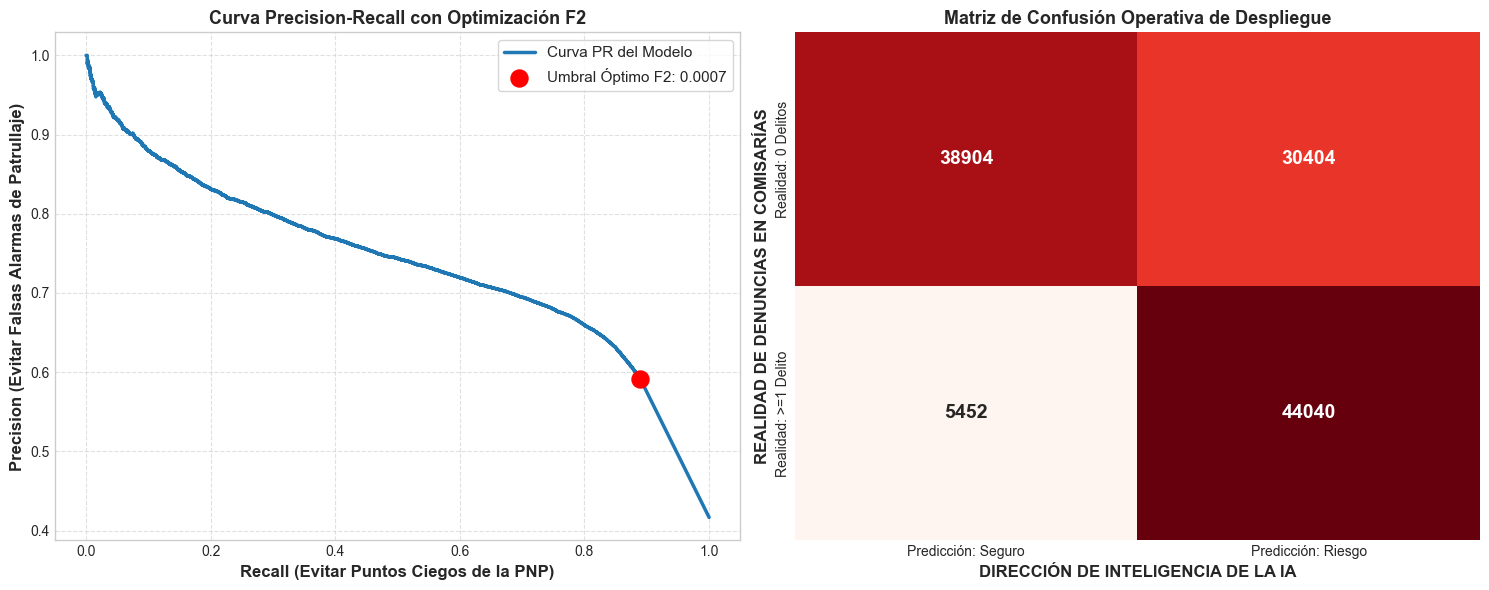

In [8]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Curva Precision-Recall
axes[0].plot(recalls, precisions, color='#1f77b4', linewidth=2.5, label='Curva PR del Modelo')
axes[0].scatter(recalls[indice_optimo], precisions[indice_optimo], color='red', s=150, zorder=5,
                label=f'Umbral Óptimo F2: {umbral_estrategico:.4f}')
axes[0].set_xlabel('Recall (Evitar Puntos Ciegos de la PNP)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precision (Evitar Falsas Alarmas de Patrullaje)', fontsize=12, fontweight='bold')
axes[0].set_title('Curva Precision-Recall con Optimización F2', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True, fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Matriz de Confusión Operativa
pred_clases = (y_predicho_real >= umbral_estrategico).astype(int)
cm = confusion_matrix(y_real_binario, pred_clases)

sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False, ax=axes[1],
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=['Predicción: Seguro', 'Predicción: Riesgo'],
            yticklabels=['Realidad: 0 Delitos', 'Realidad: >=1 Delito'])
axes[1].set_xlabel('DIRECCIÓN DE INTELIGENCIA DE LA IA', fontsize=12, fontweight='bold')
axes[1].set_ylabel('REALIDAD DE DENUNCIAS EN COMISARÍAS', fontsize=12, fontweight='bold')
axes[1].set_title('Matriz de Confusión Operativa de Despliegue', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# PASO 6: Reporte de Inteligencia Estratégica Institucional

In [7]:
print("\n" + "="*65)
print("   REPORTE OFICIAL DE MÉTRICAS PREDICTIVAS - DESPLIEGUE PREVENTIVO")
print("="*65)
print(classification_report(y_real_binario, pred_clases, target_names=['Zona Segura (Verde)', 'Zona de Riesgo (Roja)']))
print("="*65)


   REPORTE OFICIAL DE MÉTRICAS PREDICTIVAS - DESPLIEGUE PREVENTIVO
                       precision    recall  f1-score   support

  Zona Segura (Verde)       0.88      0.56      0.68     69308
Zona de Riesgo (Roja)       0.59      0.89      0.71     49492

             accuracy                           0.70    118800
            macro avg       0.73      0.73      0.70    118800
         weighted avg       0.76      0.70      0.70    118800

